In [1]:
import pandas as pd

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [4]:
noisy_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "noisy_v3"
baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"

In [5]:
noisy_recalls, noisy_precisions = get_precisions_recalls(noisy_path)
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)

In [6]:
print(f"Noisy recall: {np.array(noisy_recalls).mean(axis=0)}")
print(f"Baseline recall: {np.array(baseline_recalls).mean(axis=0)}")

Noisy recall: [3.86870101e-05 3.44846912e-02 9.76090116e-02 1.64538715e-01
 2.40813204e-01 3.30154915e-01 4.21686127e-01 5.01512832e-01
 5.66726420e-01 6.22794469e-01 6.70704398e-01 7.12147236e-01
 7.48901336e-01 7.79086982e-01 8.02646841e-01 8.21449145e-01
 8.37267371e-01 8.49809522e-01 8.60066631e-01 8.69224238e-01
 8.77336016e-01 8.85521289e-01 8.93214086e-01 9.00716935e-01
 9.07192032e-01 9.13837828e-01 9.19706028e-01 9.25190967e-01
 9.30274292e-01 9.34669180e-01 9.38710734e-01 9.42522744e-01
 9.45931159e-01 9.49015622e-01 9.51723890e-01 9.54230792e-01
 9.56806918e-01 9.59047847e-01 9.60762336e-01 9.62314148e-01
 9.63541054e-01 9.65586406e-01 9.67318204e-01 9.68778461e-01
 9.69952853e-01 9.71125122e-01 9.72139956e-01 9.73220321e-01
 9.74085136e-01 9.74715004e-01 9.75420602e-01 9.76057062e-01
 9.76789464e-01 9.77399575e-01 9.78060797e-01 9.78737202e-01
 9.79530308e-01 9.80097073e-01 9.80578716e-01 9.81067119e-01
 9.81696144e-01 9.82195440e-01 9.82818993e-01 9.83388852e-01
 9.8385683

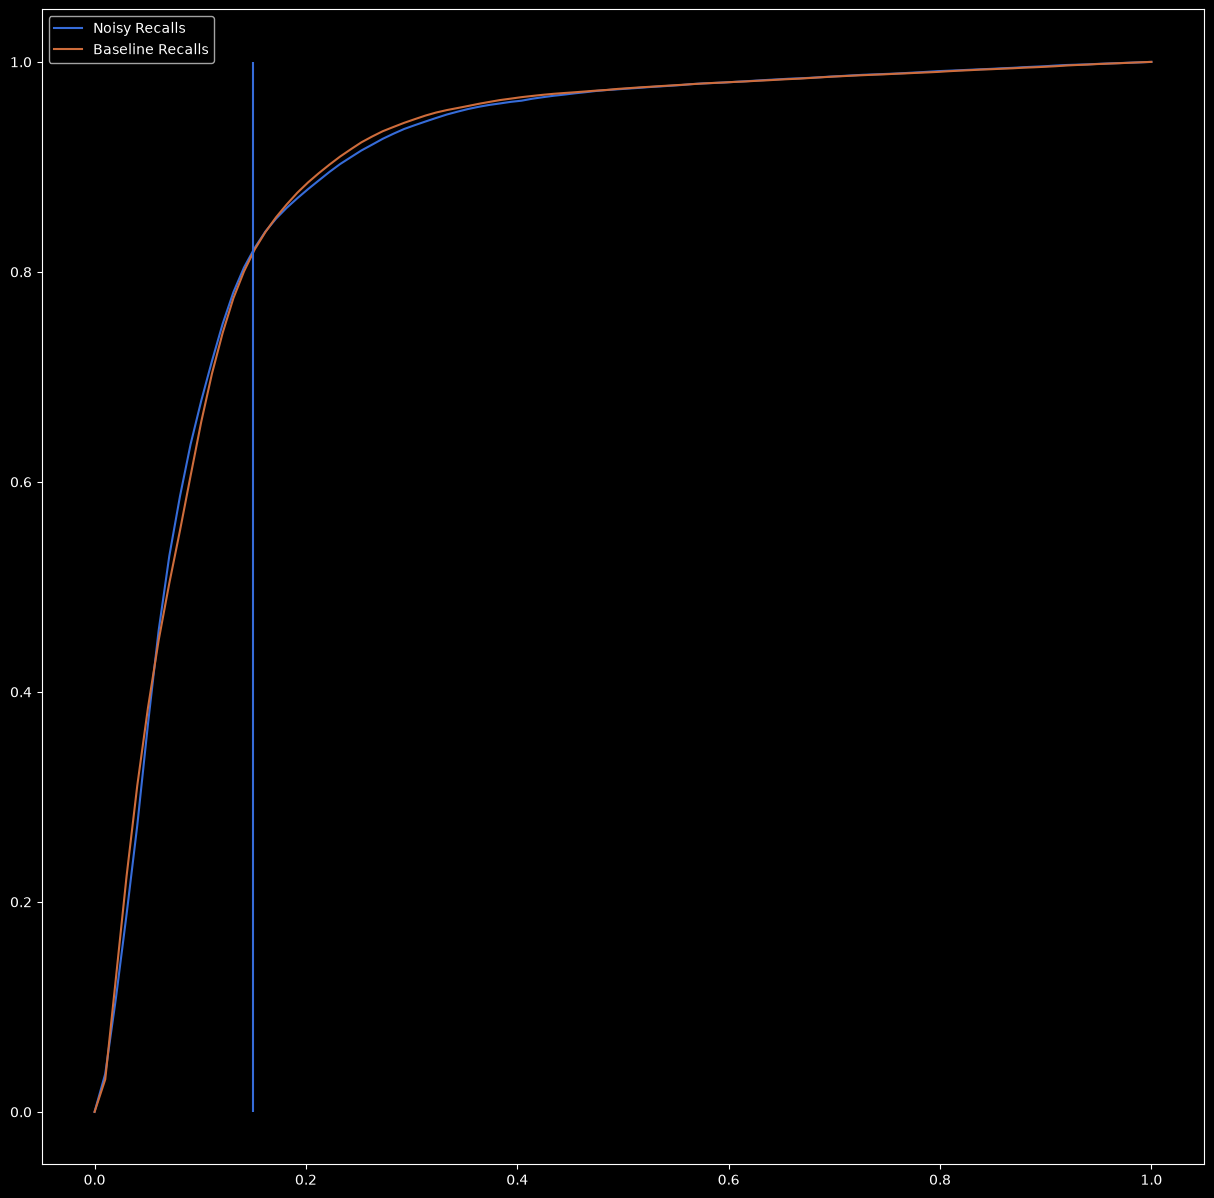

In [14]:
plt.figure(figsize=(15, 15))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(noisy_recalls[:10]).mean(axis=0), label="Noisy Recalls")
plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0),
         label="Baseline Recalls")



plt.vlines(x=0.15, ymin=0, ymax=1)
plt.legend()
plt.show()

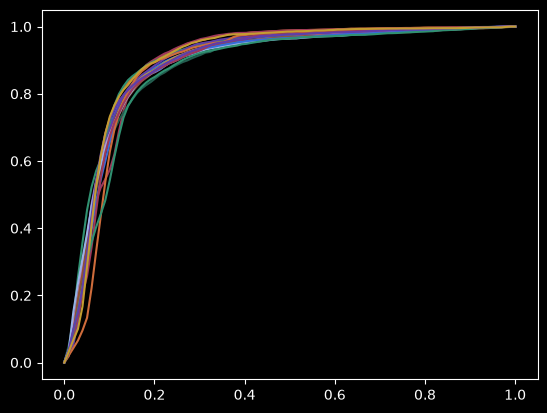

In [11]:
for i in range(len(noisy_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(noisy_recalls)[i],
         label="Noisy Recalls")

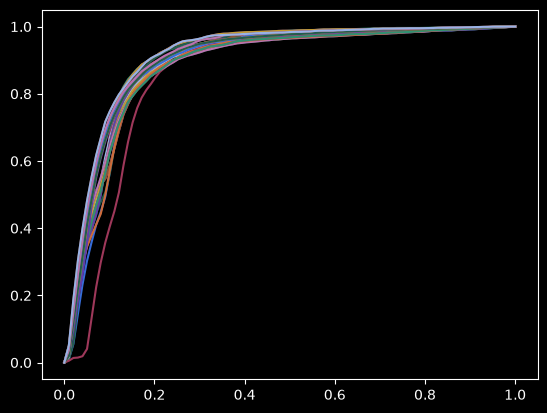

In [13]:
for i in range(len(baseline_recalls)):
    plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls)[i],
         label="Baseline Recalls")

In [10]:
noisy_recalls

[[0.0,
  0.04365945624131772,
  0.10994244889859099,
  0.17066878348878745,
  0.2433022425084342,
  0.3455050605278825,
  0.43044254812462796,
  0.5187537209763842,
  0.5896011113316134,
  0.651518158364755,
  0.7013296288946218,
  0.7386386187735661,
  0.7699940464377852,
  0.7924191307799167,
  0.8114705298670372,
  0.8279420519944434,
  0.8404445326453661,
  0.8503671363365748,
  0.8604881921016074,
  0.8714030561619368,
  0.8791426870410795,
  0.8868823179202223,
  0.8954157570946615,
  0.9017662234570352,
  0.9077197856717604,
  0.9126810875173645,
  0.9174439372891445,
  0.9228021432823973,
  0.927168088906529,
  0.931732486604485,
  0.9345108156380235,
  0.9372891446715618,
  0.941059734074221,
  0.9436396110339353,
  0.9458225838460012,
  0.9489978170271878,
  0.9509823377654296,
  0.952569954356023,
  0.9549513792419131,
  0.9569358999801548,
  0.9575312562016274,
  0.9595157769398689,
  0.9615002976781107,
  0.9644770787854733,
  0.9656677912284183,
  0.9670569557451876,
  0.